# Radial Intensity Analysis for Area Detector

This notebook provides analysis of intensity distribution as a function of radial distance from the detector center.

## Analysis Features:
- Load area detector data from GFRM files
- Calculate radial distances from detector center
- Generate radial intensity profiles
- Visualize intensity vs radial distance with multiple views
- Statistical analysis of radial intensity patterns

## Required Data:
- GFRM file from Bruker GADDS area detector

In [1]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from matplotlib.patches import Circle, Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.ndimage as ndimage
from scipy import stats
from scipy.optimize import curve_fit
from scipy.interpolate import interp2d, griddata
import os
import warnings
from gadds import AreaDetectorImage

# Set up matplotlib for high-quality plots
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
warnings.filterwarnings('ignore', category=RuntimeWarning)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Area Detector Data
# Specify the path to your GFRM file
gfrm_file = r"test\20250709_S_MeO_B01_000.gfrm"  # Update this path as needed

# Load the detector data
try:
    area_detector = AreaDetectorImage(gfrm_file)
    print(f"✓ Successfully loaded: {gfrm_file}")
    print(f"  Image shape: {area_detector.image.data.shape}")
    print(f"  Data type: {area_detector.image.data.dtype}")
    print(f"  Detector center: {area_detector.centerXY}")
    print(f"  Pixel density: {area_detector.densityXY} pixels/cm")
    
    # Get detector data
    detector_data = area_detector.image.data.astype(float)
    
    # Basic data analysis
    print(f"\n=== Data Analysis ===")
    print(f"Data range: {np.min(detector_data):.0f} - {np.max(detector_data):.0f}")
    print(f"Mean: {np.mean(detector_data):.1f}")
    print(f"Pixels > 0: {np.sum(detector_data > 0):,} ({np.sum(detector_data > 0)/detector_data.size*100:.1f}%)")
    
except Exception as e:
    print(f"❌ Error loading file: {e}")
    print("Please check that the GFRM file exists and update the path accordingly.")
    raise

  File "c:\Users\yrliu98\Documents\lbl\gaddsconverter\gadds.py", line 91, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2
  File "c:\Users\yrliu98\Documents\lbl\gaddsconverter\gadds.py", line 91, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2


✓ Successfully loaded: test\20250709_S_MeO_B01_000.gfrm
  Image shape: (2048, 2048)
  Data type: uint16
  Detector center: (1003.7000122, 1022.0999756)
  Pixel density: (147.0628052, 147.0628052) pixels/cm

=== Data Analysis ===
Data range: 0 - 1085
Mean: 1.1
Pixels > 0: 2,141,353 (51.1%)


In [3]:
# Calculate Detector Geometry and Parameters
center_x, center_y = area_detector.centerXY
y_coords, x_coords = np.ogrid[:detector_data.shape[0], :detector_data.shape[1]]

# Calculate distance from center for all pixels
dist_from_center = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)

# Estimate detector radius
# Find pixels with signal
signal_pixels = detector_data > 0
if np.any(signal_pixels):
    signal_distances = dist_from_center[signal_pixels]
    max_signal_radius = np.max(signal_distances)
    print(f"Maximum distance with signal: {max_signal_radius:.1f} pixels")
else:
    max_signal_radius = np.min([center_x, center_y, 
                              detector_data.shape[1] - center_x, 
                              detector_data.shape[0] - center_y]) * 0.9

# Use a conservative estimate for detector radius, but extend to 1100 pixels for analysis
detector_radius = max_signal_radius * 0.95
analysis_radius = 1100  # Extended radius for comprehensive analysis
signal_threshold = 500  # Counts above this are considered signal

# Create circular detector mask (for actual detector area)
detector_mask = dist_from_center <= detector_radius
# Create extended analysis mask (for plotting up to 1100 pixels)
analysis_mask = dist_from_center <= analysis_radius

print(f"\n=== Detector Geometry ===")
print(f"Detector center: ({center_x:.1f}, {center_y:.1f})")
print(f"Estimated detector radius: {detector_radius:.1f} pixels")
print(f"Analysis radius (extended): {analysis_radius} pixels")
print(f"Detector area: {np.sum(detector_mask):,} pixels")
print(f"Analysis area: {np.sum(analysis_mask):,} pixels")
print(f"Signal threshold: {signal_threshold} counts")

Maximum distance with signal: 1007.4 pixels

=== Detector Geometry ===
Detector center: (1003.7, 1022.1)
Estimated detector radius: 957.1 pixels
Analysis radius (extended): 1100 pixels
Detector area: 2,877,602 pixels
Analysis area: 3,635,295 pixels
Signal threshold: 500 counts


In [4]:
# Plot Intensity vs Radial Distance from Detector Center
# Create comprehensive radial analysis plot

# Calculate radial distances for all pixels
radial_distances = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)

# Create binned radial profile - extend to 1100 pixels
max_radius = analysis_radius  # Use extended radius instead of detector radius
bin_width = 2  # pixels
radial_bins = np.arange(0, max_radius + bin_width, bin_width)
bin_centers = radial_bins[:-1] + bin_width/2

# Calculate statistics for each radial bin
mean_intensities = []
median_intensities = []
std_intensities = []
max_intensities = []
pixel_counts = []
mean_below_75p = []  # Mean of intensities below 75th percentile
mean_below_50p = []  # Mean of intensities below 50th percentile
mean_below_90p = []  # Mean of intensities below 90th percentile
mean_below_95p = []  # Mean of intensities below 95th percentile

print("Calculating radial intensity profile...")

for i in range(len(radial_bins)-1):
    r_min = radial_bins[i]
    r_max = radial_bins[i+1]
    
    # Create ring mask - use analysis mask to include areas beyond detector
    ring_mask = (radial_distances >= r_min) & (radial_distances < r_max) & analysis_mask
    
    if np.any(ring_mask):
        ring_intensities = detector_data[ring_mask]
        # Only consider non-zero pixels for meaningful statistics
        non_zero_intensities = ring_intensities[ring_intensities > 0]
        
        if len(non_zero_intensities) > 0:
            mean_intensities.append(np.mean(non_zero_intensities))
            median_intensities.append(np.median(non_zero_intensities))
            std_intensities.append(np.std(non_zero_intensities))
            max_intensities.append(np.max(non_zero_intensities))
            pixel_counts.append(len(non_zero_intensities))
            
            # Calculate truncated means (mean of values below percentiles)
            p75_threshold = np.percentile(non_zero_intensities, 75)
            p50_threshold = np.percentile(non_zero_intensities, 50)
            p90_threshold = np.percentile(non_zero_intensities, 90)
            p95_threshold = np.percentile(non_zero_intensities, 95)
            
            below_75p = non_zero_intensities[non_zero_intensities <= p75_threshold]
            below_50p = non_zero_intensities[non_zero_intensities <= p50_threshold]
            below_90p = non_zero_intensities[non_zero_intensities <= p90_threshold]
            below_95p = non_zero_intensities[non_zero_intensities <= p95_threshold]
            
            mean_below_75p.append(np.mean(below_75p) if len(below_75p) > 0 else 0)
            mean_below_50p.append(np.mean(below_50p) if len(below_50p) > 0 else 0)
            mean_below_90p.append(np.mean(below_90p) if len(below_90p) > 0 else 0)
            mean_below_95p.append(np.mean(below_95p) if len(below_95p) > 0 else 0)
        else:
            mean_intensities.append(0)
            median_intensities.append(0)
            std_intensities.append(0)
            max_intensities.append(0)
            pixel_counts.append(0)
            mean_below_75p.append(0)
            mean_below_50p.append(0)
            mean_below_90p.append(0)
            mean_below_95p.append(0)
    else:
        mean_intensities.append(0)
        median_intensities.append(0)
        std_intensities.append(0)
        max_intensities.append(0)
        pixel_counts.append(0)
        mean_below_75p.append(0)
        mean_below_50p.append(0)
        mean_below_90p.append(0)
        mean_below_95p.append(0)

# Convert to arrays
mean_intensities = np.array(mean_intensities)
median_intensities = np.array(median_intensities)
std_intensities = np.array(std_intensities)
max_intensities = np.array(max_intensities)
pixel_counts = np.array(pixel_counts)
mean_below_75p = np.array(mean_below_75p)
mean_below_50p = np.array(mean_below_50p)
mean_below_90p = np.array(mean_below_90p)
mean_below_95p = np.array(mean_below_95p)

print(f"Radial profile calculated with {len(bin_centers)} bins")

Calculating radial intensity profile...
Radial profile calculated with 550 bins


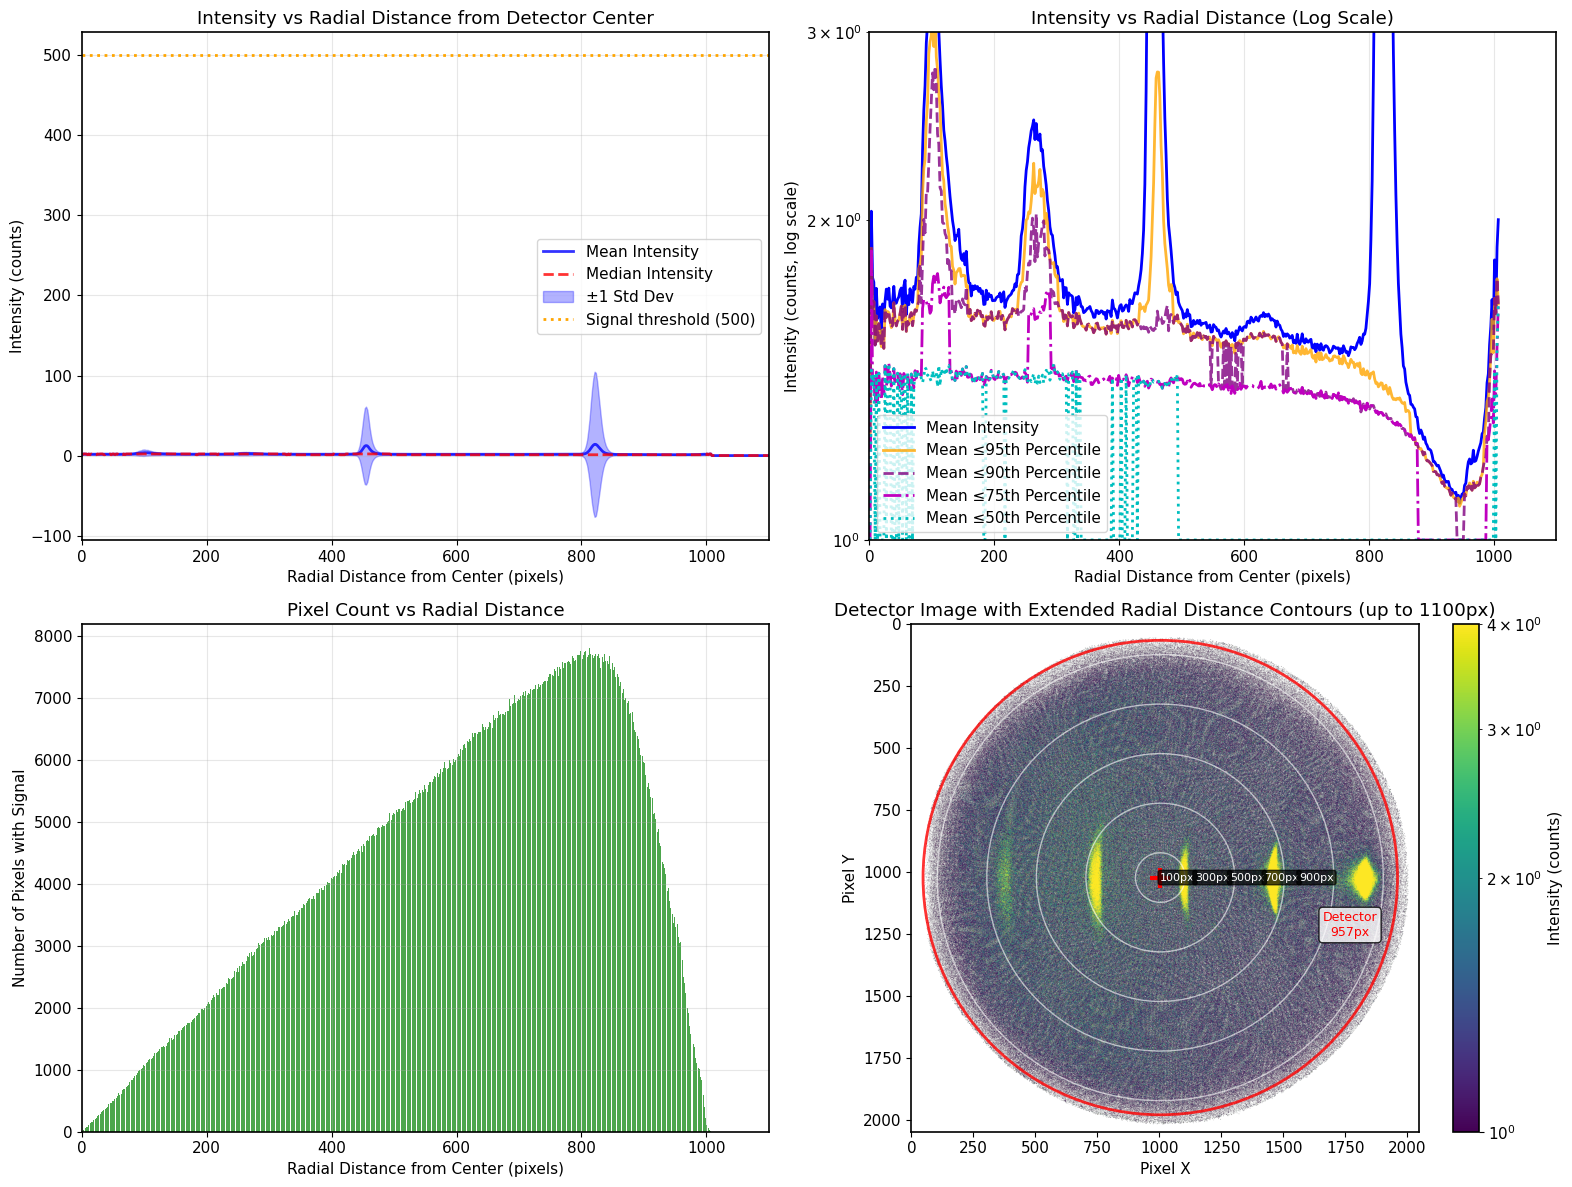

In [5]:
# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mean and Median Intensity vs Radial Distance
ax1.plot(bin_centers, mean_intensities, 'b-', linewidth=2, label='Mean Intensity', alpha=0.8)
ax1.plot(bin_centers, median_intensities, 'r--', linewidth=2, label='Median Intensity', alpha=0.8)
ax1.fill_between(bin_centers, mean_intensities - std_intensities, 
                mean_intensities + std_intensities, alpha=0.3, color='blue', label='±1 Std Dev')
ax1.axhline(signal_threshold, color='orange', linestyle=':', linewidth=2, label=f'Signal threshold ({signal_threshold})')
ax1.set_xlabel('Radial Distance from Center (pixels)')
ax1.set_ylabel('Intensity (counts)')
ax1.set_title('Intensity vs Radial Distance from Detector Center')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max_radius)

# Plot 2: Log scale for better dynamic range visualization
# Filter out zero values for log plot
valid_mean = mean_intensities > 0
valid_median = median_intensities > 0
valid_max = max_intensities > 0
valid_mean_75p = mean_below_75p > 0
valid_mean_50p = mean_below_50p > 0
valid_mean_90p = mean_below_90p > 0
valid_mean_95p = mean_below_95p > 0

if np.any(valid_mean):
    ax2.semilogy(bin_centers[valid_mean], mean_intensities[valid_mean], 'b-', linewidth=2, label='Mean Intensity')
# if np.any(valid_median):
#     ax2.semilogy(bin_centers[valid_median], median_intensities[valid_median], 'r--', linewidth=2, label='Median Intensity')
# if np.any(valid_max):
#     ax2.semilogy(bin_centers[valid_max], max_intensities[valid_max], 'g:', linewidth=2, label='Max Intensity')
if np.any(valid_mean_95p):
    ax2.semilogy(bin_centers[valid_mean_95p], mean_below_95p[valid_mean_95p], 'orange', linestyle='-', linewidth=2, alpha=0.8, label='Mean ≤95th Percentile')
if np.any(valid_mean_90p):
    ax2.semilogy(bin_centers[valid_mean_90p], mean_below_90p[valid_mean_90p], 'purple', linestyle='--', linewidth=2, alpha=0.8, label='Mean ≤90th Percentile')
if np.any(valid_mean_75p):
    ax2.semilogy(bin_centers[valid_mean_75p], mean_below_75p[valid_mean_75p], 'm-.', linewidth=2, label='Mean ≤75th Percentile')
if np.any(valid_mean_50p):
    ax2.semilogy(bin_centers[valid_mean_50p], mean_below_50p[valid_mean_50p], 'c:', linewidth=2, label='Mean ≤50th Percentile')

# ax2.axhline(signal_threshold, color='orange', linestyle=':', linewidth=2, label=f'Signal threshold ({signal_threshold})')
ax2.set_xlabel('Radial Distance from Center (pixels)')
ax2.set_ylabel('Intensity (counts, log scale)')
ax2.set_title('Intensity vs Radial Distance (Log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max_radius)
if np.any(valid_max):
    ax2.set_ylim(1, 3)

# Plot 3: Number of pixels per radial bin
ax3.bar(bin_centers, pixel_counts, width=bin_width*0.8, alpha=0.7, color='green')
ax3.set_xlabel('Radial Distance from Center (pixels)')
ax3.set_ylabel('Number of Pixels with Signal')
ax3.set_title('Pixel Count vs Radial Distance')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max_radius)

# Plot 4: 2D detector image with radial distance overlay
# Create masked data for display (NaN outside analysis area)
detector_data_masked = detector_data.copy()
detector_data_masked[~analysis_mask] = np.nan

# Use appropriate normalization based on data range
data_max = np.nanpercentile(detector_data_masked, 99)
data_min = np.nanmin(detector_data_masked[detector_data_masked > 0]) if np.any(detector_data_masked > 0) else 1

im = ax4.imshow(detector_data_masked, cmap='viridis', 
               norm=colors.LogNorm(vmin=max(data_min, 1), vmax=data_max))

# Add radial distance contours - extend to full analysis range
contour_radii = np.arange(100, analysis_radius, 200)  # Every 200 pixels up to 1100
theta = np.linspace(0, 2*np.pi, 100)
for radius in contour_radii:
    if radius < analysis_radius:
        circle_x = center_x + radius * np.cos(theta)
        circle_y = center_y + radius * np.sin(theta)
        ax4.plot(circle_x, circle_y, 'white', alpha=0.6, linewidth=1)
        # Add radius labels
        ax4.text(center_x + radius*0.7, center_y, f'{radius:.0f}px', 
                color='white', fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

# Also show the actual detector boundary
detector_circle = Circle((center_x, center_y), detector_radius, fill=False, color='red', linewidth=2, alpha=0.8)
ax4.add_patch(detector_circle)
ax4.text(center_x + detector_radius*0.8, center_y + detector_radius*0.2, 
         f'Detector\n{detector_radius:.0f}px', color='red', fontsize=9, ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax4.plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=3)
ax4.set_title('Detector Image with Extended Radial Distance Contours (up to 1100px)')
ax4.set_xlabel('Pixel X')
ax4.set_ylabel('Pixel Y')
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Intensity (counts)')

plt.tight_layout()
plt.show()

In [24]:
# Statistical Analysis and Summary
print(f"\n=== Radial Intensity Analysis Summary ===")
print(f"Radial bins analyzed: {len(bin_centers)}")
print(f"Bin width: {bin_width} pixels")
print(f"Maximum radial distance analyzed: {max_radius} pixels")
print(f"Actual detector radius: {detector_radius:.1f} pixels")

# Find peak intensity location
if np.any(mean_intensities > 0):
    peak_idx = np.argmax(mean_intensities)
    peak_radius = bin_centers[peak_idx]
    peak_intensity = mean_intensities[peak_idx]
    
    print(f"Peak intensity location: {peak_radius:.1f} pixels from center")
    print(f"Peak intensity value: {peak_intensity:.1f} counts")
    
    # Analyze intensity decay with radius
    valid_data = mean_intensities > 0
    if np.sum(valid_data) > 10:
        # Calculate correlation between radius and intensity
        valid_radii = bin_centers[valid_data]
        valid_intensities = mean_intensities[valid_data]
        
        correlation = np.corrcoef(valid_radii, valid_intensities)[0, 1]
        print(f"Correlation between radius and intensity: {correlation:.3f}")
        
        # Find the radius where intensity drops to 50% of peak
        half_peak = peak_intensity * 0.5
        half_peak_idx = np.where(mean_intensities < half_peak)[0]
        if len(half_peak_idx) > 0:
            half_peak_radius = bin_centers[half_peak_idx[0]]
            print(f"Radius where intensity drops to 50% of peak: {half_peak_radius:.1f} pixels")
        
        # Calculate average intensity in different radial zones
        center_zone = bin_centers < max_radius * 0.3
        middle_zone = (bin_centers >= max_radius * 0.3) & (bin_centers < max_radius * 0.7)
        edge_zone = bin_centers >= max_radius * 0.7
        
        if np.any(center_zone & valid_data):
            center_intensity = np.mean(mean_intensities[center_zone & valid_data])
            print(f"Average intensity in center zone (0-30% radius): {center_intensity:.1f} counts")
        
        if np.any(middle_zone & valid_data):
            middle_intensity = np.mean(mean_intensities[middle_zone & valid_data])
            print(f"Average intensity in middle zone (30-70% radius): {middle_intensity:.1f} counts")
        
        if np.any(edge_zone & valid_data):
            edge_intensity = np.mean(mean_intensities[edge_zone & valid_data])
            print(f"Average intensity in edge zone (70-100% radius): {edge_intensity:.1f} counts")
    
    print("\nRadial intensity analysis complete!")
else:
    print("No valid intensity data found. Check detector data and file path.")


=== Radial Intensity Analysis Summary ===
Radial bins analyzed: 550
Bin width: 2 pixels
Maximum radial distance analyzed: 1100 pixels
Actual detector radius: 957.1 pixels
Peak intensity location: 821.0 pixels from center
Peak intensity value: 14.0 counts
Correlation between radius and intensity: -0.004
Radius where intensity drops to 50% of peak: 1.0 pixels
Average intensity in center zone (0-30% radius): 2.0 counts
Average intensity in middle zone (30-70% radius): 2.0 counts
Average intensity in edge zone (70-100% radius): 2.3 counts

Radial intensity analysis complete!


=== Investigating Intensity Dip Between 900-1000 Pixels ===
Dip region (900-1000px):
  Mean intensity: 1.2 counts
  Median intensity: 1.2 counts
  Average pixel count per bin: 3212
  Total pixels with signal: 160,607

Normal region (800-850px):
  Mean intensity: 6.1 counts
  Median intensity: 4.5 counts
  Average pixel count per bin: 7654
  Total pixels with signal: 191,355

Intensity ratio (dip/normal): 0.198
Intensity reduction: 80.2%

=== Detailed Statistics ===
Dip region pixel statistics:
  Count: 160,607
  Mean: 1.2
  Median: 1.0
  Std: 0.4
  Range: 1 - 9

Normal region pixel statistics:
  Count: 191,355
  Mean: 6.1
  Median: 1.0
  Std: 45.7
  Range: 1 - 1085


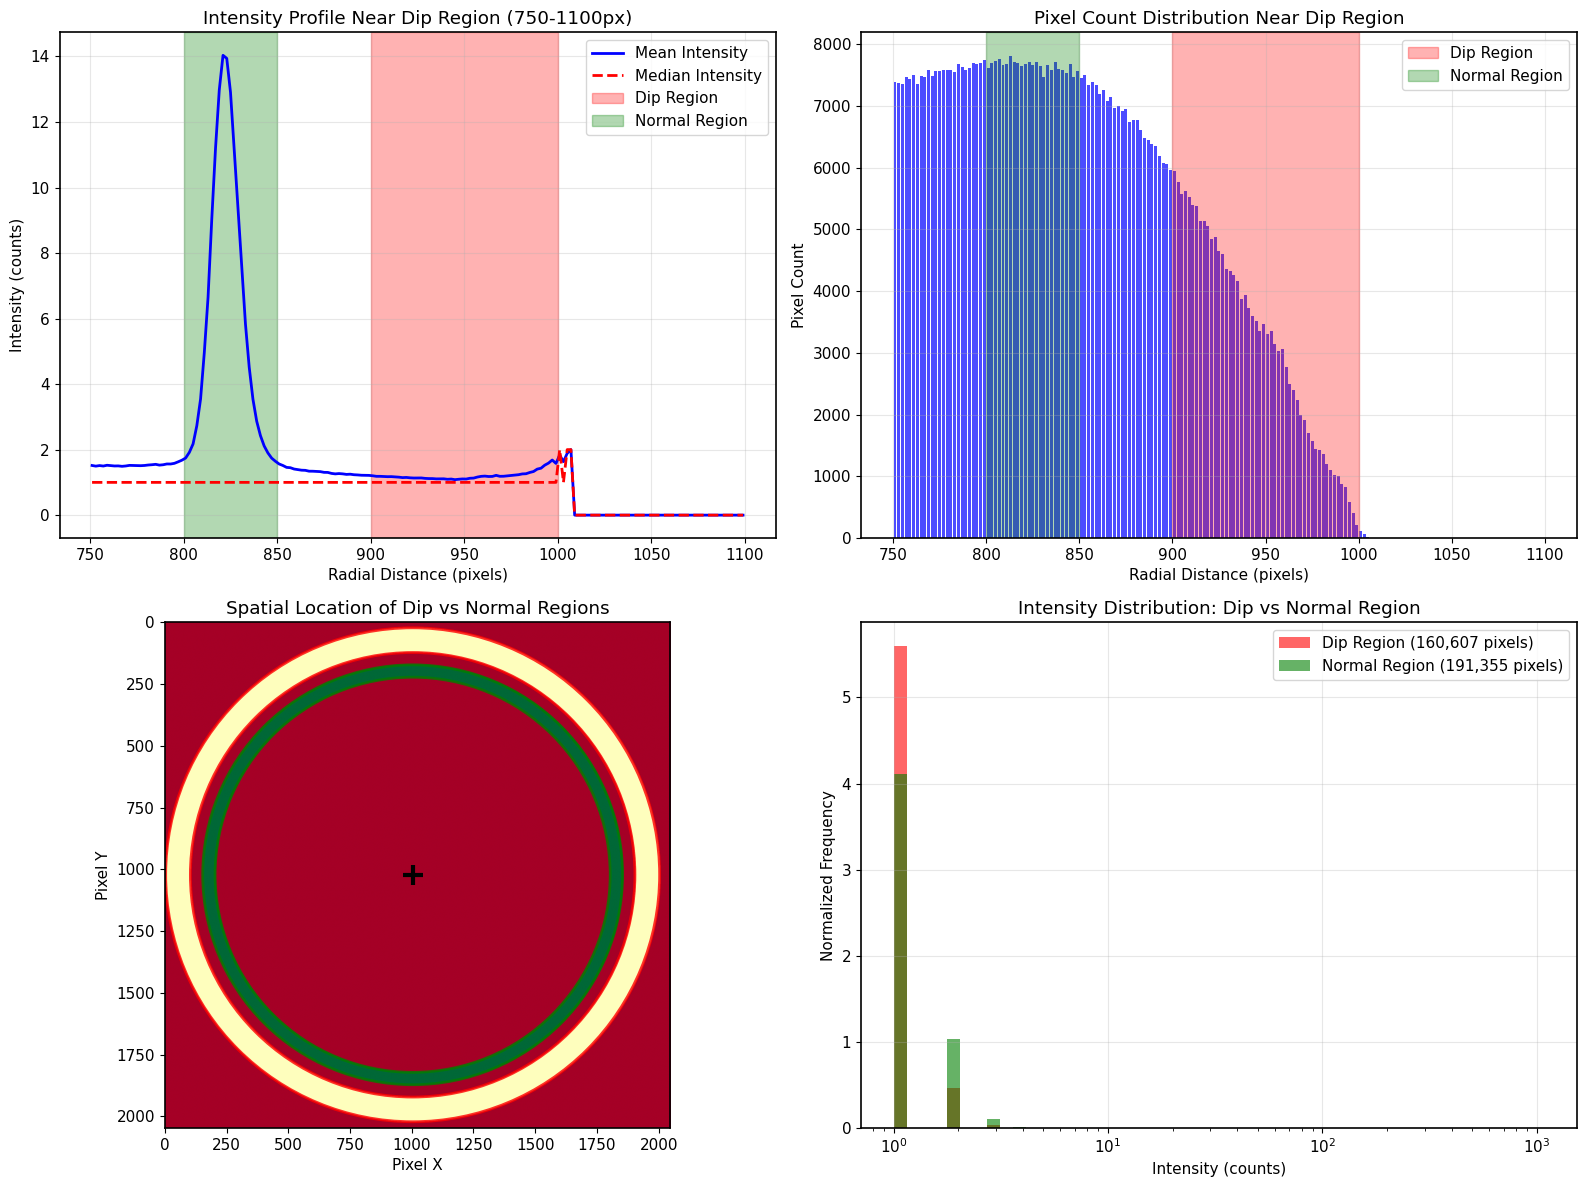


=== Potential Causes Analysis ===
1. Detector boundary effects:
   Actual detector radius: 957.1 pixels
   Dip center: 950.0 pixels
   Distance beyond detector: -7.1 pixels

2. Image boundary effects:
   Image shape: (2048, 2048)
   Max possible radius: 1024.0 pixels
   Distance from image edge: 74.0 pixels

3. Data availability:
   Total pixels in dip region: 596,929
   Total pixels in normal region: 259,170
   Pixel density ratio (dip/normal): 2.303

=== Investigation Complete ===
The dip could be caused by:
1. Detector edge effects (if near physical detector boundary)
2. Image acquisition boundary effects
3. Geometric sampling effects (fewer pixels at certain radii)
4. Systematic instrumental artifacts
5. Physical obstruction or detector design features


In [25]:
# Investigate the Intensity Dip Between 900-1000 Pixels
print("=== Investigating Intensity Dip Between 900-1000 Pixels ===")

# Define the region of interest
dip_start = 900
dip_end = 1000
normal_start = 800
normal_end = 850

# Find corresponding bin indices
dip_indices = (bin_centers >= dip_start) & (bin_centers <= dip_end)
normal_indices = (bin_centers >= normal_start) & (bin_centers <= normal_end)

if np.any(dip_indices) and np.any(normal_indices):
    # Extract intensity values for comparison
    dip_intensities = mean_intensities[dip_indices]
    normal_intensities = mean_intensities[normal_indices]
    
    dip_pixel_counts = pixel_counts[dip_indices]
    normal_pixel_counts = pixel_counts[normal_indices]
    
    print(f"Dip region ({dip_start}-{dip_end}px):")
    print(f"  Mean intensity: {np.mean(dip_intensities[dip_intensities > 0]):.1f} counts")
    print(f"  Median intensity: {np.median(dip_intensities[dip_intensities > 0]):.1f} counts")
    print(f"  Average pixel count per bin: {np.mean(dip_pixel_counts):.0f}")
    print(f"  Total pixels with signal: {np.sum(dip_pixel_counts):,}")
    
    print(f"\nNormal region ({normal_start}-{normal_end}px):")
    print(f"  Mean intensity: {np.mean(normal_intensities[normal_intensities > 0]):.1f} counts")
    print(f"  Median intensity: {np.median(normal_intensities[normal_intensities > 0]):.1f} counts")
    print(f"  Average pixel count per bin: {np.mean(normal_pixel_counts):.0f}")
    print(f"  Total pixels with signal: {np.sum(normal_pixel_counts):,}")
    
    # Calculate intensity ratio
    if np.mean(normal_intensities[normal_intensities > 0]) > 0:
        intensity_ratio = np.mean(dip_intensities[dip_intensities > 0]) / np.mean(normal_intensities[normal_intensities > 0])
        print(f"\nIntensity ratio (dip/normal): {intensity_ratio:.3f}")
        print(f"Intensity reduction: {(1-intensity_ratio)*100:.1f}%")

# Create detailed visualization of the dip region
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Zoomed view of the dip region
zoom_indices = (bin_centers >= 750) & (bin_centers <= 1100)
if np.any(zoom_indices):
    ax1.plot(bin_centers[zoom_indices], mean_intensities[zoom_indices], 'b-', linewidth=2, label='Mean Intensity')
    ax1.plot(bin_centers[zoom_indices], median_intensities[zoom_indices], 'r--', linewidth=2, label='Median Intensity')
    ax1.axvspan(dip_start, dip_end, alpha=0.3, color='red', label='Dip Region')
    ax1.axvspan(normal_start, normal_end, alpha=0.3, color='green', label='Normal Region')
    ax1.set_xlabel('Radial Distance (pixels)')
    ax1.set_ylabel('Intensity (counts)')
    ax1.set_title('Intensity Profile Near Dip Region (750-1100px)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Plot 2: Pixel count in the region
ax2.bar(bin_centers[zoom_indices], pixel_counts[zoom_indices], width=bin_width*0.8, alpha=0.7, color='blue')
ax2.axvspan(dip_start, dip_end, alpha=0.3, color='red', label='Dip Region')
ax2.axvspan(normal_start, normal_end, alpha=0.3, color='green', label='Normal Region')
ax2.set_xlabel('Radial Distance (pixels)')
ax2.set_ylabel('Pixel Count')
ax2.set_title('Pixel Count Distribution Near Dip Region')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: 2D analysis - show specific radial rings
dip_mask = (radial_distances >= dip_start) & (radial_distances <= dip_end) & analysis_mask
normal_mask = (radial_distances >= normal_start) & (radial_distances <= normal_end) & analysis_mask

# Create visualization showing where these pixels are located
analysis_image = np.zeros_like(detector_data)
analysis_image[dip_mask] = 1  # Red for dip region
analysis_image[normal_mask] = 2  # Green for normal region

im3 = ax3.imshow(analysis_image, cmap='RdYlGn', vmin=0, vmax=2)
ax3.plot(center_x, center_y, 'k+', markersize=15, markeredgewidth=3)

# Add circles to show the regions
theta = np.linspace(0, 2*np.pi, 100)
dip_circle_inner = Circle((center_x, center_y), dip_start, fill=False, color='red', linewidth=2, alpha=0.8)
dip_circle_outer = Circle((center_x, center_y), dip_end, fill=False, color='red', linewidth=2, alpha=0.8)
normal_circle_inner = Circle((center_x, center_y), normal_start, fill=False, color='green', linewidth=2, alpha=0.8)
normal_circle_outer = Circle((center_x, center_y), normal_end, fill=False, color='green', linewidth=2, alpha=0.8)

ax3.add_patch(dip_circle_inner)
ax3.add_patch(dip_circle_outer)
ax3.add_patch(normal_circle_inner)
ax3.add_patch(normal_circle_outer)

ax3.set_title('Spatial Location of Dip vs Normal Regions')
ax3.set_xlabel('Pixel X')
ax3.set_ylabel('Pixel Y')

# Plot 4: Statistical comparison
if np.any(dip_mask) and np.any(normal_mask):
    dip_pixels = detector_data[dip_mask]
    normal_pixels = detector_data[normal_mask]
    
    # Remove zeros for meaningful comparison
    dip_pixels_nz = dip_pixels[dip_pixels > 0]
    normal_pixels_nz = normal_pixels[normal_pixels > 0]
    
    if len(dip_pixels_nz) > 0 and len(normal_pixels_nz) > 0:
        # Create histograms
        bins = np.logspace(0, np.log10(max(np.max(dip_pixels_nz), np.max(normal_pixels_nz))), 50)
        ax4.hist(dip_pixels_nz, bins=bins, alpha=0.6, label=f'Dip Region ({len(dip_pixels_nz):,} pixels)', 
                color='red', density=True)
        ax4.hist(normal_pixels_nz, bins=bins, alpha=0.6, label=f'Normal Region ({len(normal_pixels_nz):,} pixels)', 
                color='green', density=True)
        ax4.set_xscale('log')
        ax4.set_xlabel('Intensity (counts)')
        ax4.set_ylabel('Normalized Frequency')
        ax4.set_title('Intensity Distribution: Dip vs Normal Region')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # Print detailed statistics
        print(f"\n=== Detailed Statistics ===")
        print(f"Dip region pixel statistics:")
        print(f"  Count: {len(dip_pixels_nz):,}")
        print(f"  Mean: {np.mean(dip_pixels_nz):.1f}")
        print(f"  Median: {np.median(dip_pixels_nz):.1f}")
        print(f"  Std: {np.std(dip_pixels_nz):.1f}")
        print(f"  Range: {np.min(dip_pixels_nz):.0f} - {np.max(dip_pixels_nz):.0f}")
        
        print(f"\nNormal region pixel statistics:")
        print(f"  Count: {len(normal_pixels_nz):,}")
        print(f"  Mean: {np.mean(normal_pixels_nz):.1f}")
        print(f"  Median: {np.median(normal_pixels_nz):.1f}")
        print(f"  Std: {np.std(normal_pixels_nz):.1f}")
        print(f"  Range: {np.min(normal_pixels_nz):.0f} - {np.max(normal_pixels_nz):.0f}")

plt.tight_layout()
plt.show()

# Analyze potential causes
print(f"\n=== Potential Causes Analysis ===")

# Check if it's related to detector geometry
print(f"1. Detector boundary effects:")
print(f"   Actual detector radius: {detector_radius:.1f} pixels")
print(f"   Dip center: {(dip_start + dip_end)/2:.1f} pixels")
print(f"   Distance beyond detector: {(dip_start + dip_end)/2 - detector_radius:.1f} pixels")

# Check image boundaries
print(f"\n2. Image boundary effects:")
print(f"   Image shape: {detector_data.shape}")
print(f"   Max possible radius: {min(detector_data.shape[0]/2, detector_data.shape[1]/2):.1f} pixels")
print(f"   Distance from image edge: {min(detector_data.shape[0]/2, detector_data.shape[1]/2) - (dip_start + dip_end)/2:.1f} pixels")

# Check for systematic patterns
print(f"\n3. Data availability:")
total_dip_pixels = np.sum((radial_distances >= dip_start) & (radial_distances <= dip_end) & analysis_mask)
total_normal_pixels = np.sum((radial_distances >= normal_start) & (radial_distances <= normal_end) & analysis_mask)
print(f"   Total pixels in dip region: {total_dip_pixels:,}")
print(f"   Total pixels in normal region: {total_normal_pixels:,}")
print(f"   Pixel density ratio (dip/normal): {total_dip_pixels/total_normal_pixels:.3f}")

print(f"\n=== Investigation Complete ===")
print("The dip could be caused by:")
print("1. Detector edge effects (if near physical detector boundary)")
print("2. Image acquisition boundary effects")
print("3. Geometric sampling effects (fewer pixels at certain radii)")
print("4. Systematic instrumental artifacts")
print("5. Physical obstruction or detector design features")

## Usage Notes

### To use this notebook:

1. **Update the file path** in cell 2 to point to your GFRM file
2. **Run all cells** sequentially from top to bottom
3. **Adjust parameters** if needed:
   - `bin_width`: Size of radial bins (default: 2 pixels)
   - `signal_threshold`: Threshold to distinguish signal from background (default: 500 counts)

### Output includes:
- Four-panel visualization showing intensity vs radial distance
- Statistical analysis of radial intensity patterns
- Peak intensity location and decay characteristics
- Zonal analysis (center, middle, edge regions)

### Dependencies:
- numpy, matplotlib, scipy (standard scientific Python stack)
- Custom `gadds` module for reading GFRM files